In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def imshow(image= None):
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

In [4]:
def color_detection(image, contour):

  image = cv.cvtColor(image, cv.COLOR_BGR2HSV)
  # create mask and pixels
  mask = np.zeros(image.shape[:2], np.uint8)
  cv.drawContours(mask, [contour], -1, 255, -1)
  pixels = image[mask == 255]

  # hsv
  mean_hue = np.mean(pixels[:, 0])
  mean_saturation = np.mean(pixels[:, 1])
  mean_value = np.mean(pixels[:, 2])

  # color
  if mean_hue < 10 or mean_hue > 160:
    color = "Red"
  elif mean_hue < 25:
      color = "Orange"
  elif mean_hue < 35:
      color = "Yellow"
  elif mean_hue < 85:
      color = "Green"
  elif mean_hue < 100:
      color = "Cyan"
  elif mean_hue < 130:
      color = "Blue"
  elif mean_hue < 160:
      color = "Purple"
  else:
      color = "Unknown"


  return color


In [5]:
def detected_shape(approx):
  points = approx.reshape(4, 2)
  A = points[0]
  B = points[1]
  C = points[2]
  D = points[3]

  AB = np.linalg.norm(A - B)
  BC = np.linalg.norm(B - C)
  CD = np.linalg.norm(C - D)
  DA = np.linalg.norm(D - A)

  angle_A = np.dot(A, B)
  right_angle = abs(angle_A - 90) < 5
  equal_side = (
      abs(AB - BC) < 5 and
      abs(BC - CD) < 5 and
      abs(CD - DA) < 5 and
      abs(DA - AB) < 5
  )

  if equal_side:
    if right_angle:
      return "Square"
    else:
      return "rhombus"
  else:
    if right_angle:
      return "Rectangle"
    else:
      return "Parallelogram"

In [27]:
def calc(contour):
  # Extract geometric features from a contour including
  # area, perimeter, and centroid coordinates.
  area = cv.contourArea(contour)
  perimeter = cv.arcLength(contour, True)
  M = cv.moments(contour)
  if(M["m00"] != 0):
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
  else:
    cx = 0
    cy = 0
  cx = int(M["m10"] / M["m00"])
  cy = int(M["m01"] / M["m00"])
  center = (cx, cy)
  aspect_ratio = w / h
  return area, perimeter, center, aspect_ratio

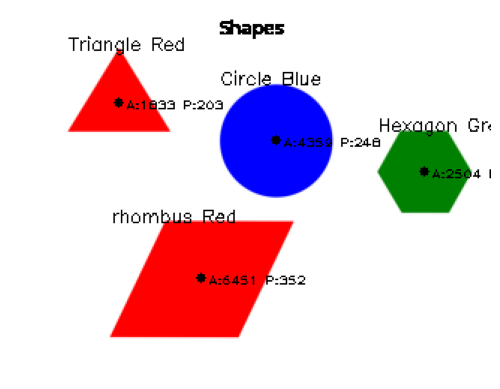

In [25]:
image = cv.imread("/content/drive/MyDrive/Colab Notebooks/Image/shapes.png")
# convert to gray scale
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# find contour
ret, threshold = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
contours, hierarchy = cv.findContours(threshold, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
# detected shpe
shape = ""
color = ""
for cnt in contours:

    if cv.contourArea(cnt) < 100:
        continue
    approx = cv.approxPolyDP(
        cnt,
        0.03 * cv.arcLength(cnt, True),
        True
    )

    area, perimeter, center, aspect_ratio = calc(cnt)
    cv.putText(
        image,
        f"A:{area:.0f} P:{perimeter:.0f}",
        (center[0] + 5, center[1] + 5),
        cv.FONT_HERSHEY_PLAIN,
        0.6,
        (0, 0, 0),
        1
    )
    cv.circle(image, center, 3, (0, 0, 0), -1)



    color = color_detection(image, cnt)
    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        shape = detected_shape(approx)
    elif len(approx) == 5:
        shape = "Pentagon"
    elif len(approx) == 6:
        shape = "Hexagon"
    elif len(approx) >= 7:
        shape = "Circle"
    else:
        shape = "Unknown"

    x, y, w, h = cv.boundingRect(cnt)
    cv.putText(
        image,
        f"{shape} {color}",
        (x, y),
        cv.FONT_HERSHEY_SIMPLEX,
        0.4,
        (0, 0, 0),
        1
    )

imshow(image= image)

